<a href="https://colab.research.google.com/github/KDY-RiskManager/risk-management-portfolio/blob/main/01-market-risk/market_risk_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm

fontpath = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
!pip install finance-datareader --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 288.3 kB/s eta 0:00:00


In [4]:
import FinanceDataReader as fdr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = fdr.DataReader('KS200', '2021-01-01', '2026-08-01')
df = df[['Close']]
df.head()

,Close
Date,
2021-01-04,399.88
2021-01-05,406.03
2021-01-06,402.08
2021-01-07,410.81
2021-01-08,430.22


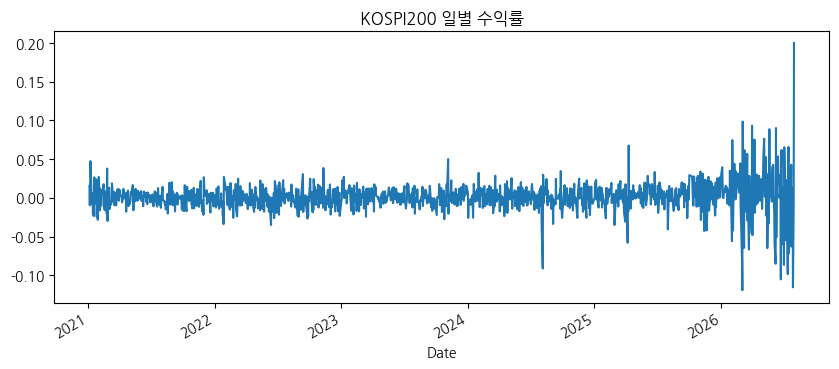

In [5]:
df['Return'] = df['Close'].pct_change()
df = df.dropna()
df['Return'].plot(title='KOSPI200 일별 수익률', figsize=(10,4))
plt.show()

In [6]:
confidence_levels = [0.95, 0.99]
for cl in confidence_levels:
    var = -np.percentile(df['Return'], (1-cl)*100)
    print(f"신뢰수준 {int(cl*100)}%, Historical VaR: {var:.4f} ({var*100:.2f}%)")

신뢰수준 95%, Historical VaR: 0.0223 (2.23%)
신뢰수준 99%, Historical VaR: 0.0608 (6.08%)


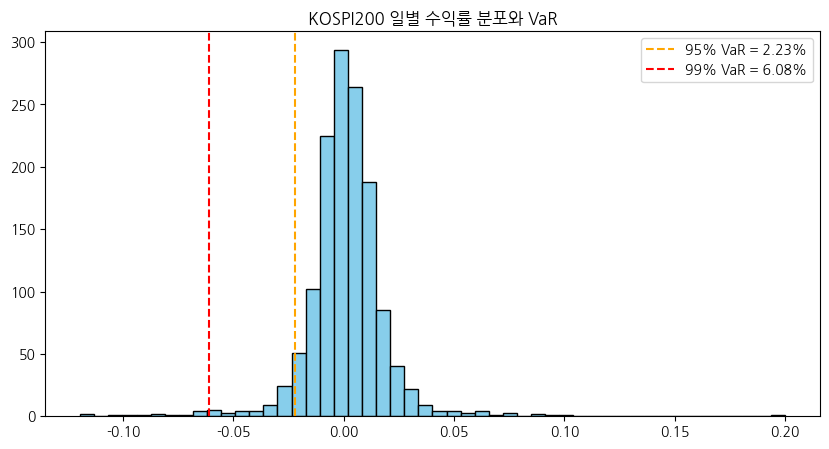

In [7]:
plt.figure(figsize=(10,5))
plt.hist(df['Return'], bins=50, color='skyblue', edgecolor='black')
var_95 = -np.percentile(df['Return'], 5)
var_99 = -np.percentile(df['Return'], 1)
plt.axvline(-var_95, color='orange', linestyle='--', label=f'95% VaR = {var_95:.2%}')
plt.axvline(-var_99, color='red', linestyle='--', label=f'99% VaR = {var_99:.2%}')
plt.legend()
plt.title('KOSPI200 일별 수익률 분포와 VaR')
plt.show()

In [8]:
portfolio_value = 100_000_000  # 예시: 1억원 포트폴리오 가정
print(f"95% 신뢰수준에서 하루 최대 예상 손실: {portfolio_value*var_95:,.0f}원")
print(f"99% 신뢰수준에서 하루 최대 예상 손실: {portfolio_value*var_99:,.0f}원")

95% 신뢰수준에서 하루 최대 예상 손실: 2,225,137원
99% 신뢰수준에서 하루 최대 예상 손실: 6,083,087원


In [9]:
exceptions_95 = (df['Return'] < -var_95).sum()
exceptions_99 = (df['Return'] < -var_99).sum()
total_days = len(df)

print(f"전체 관측일수: {total_days}일")
print(f"95% VaR 초과 횟수: {exceptions_95}회 (이론적 기대치: 약 {total_days*0.05:.1f}회)")
print(f"99% VaR 초과 횟수: {exceptions_99}회 (이론적 기대치: 약 {total_days*0.01:.1f}회)")

전체 관측일수: 1366일
95% VaR 초과 횟수: 69회 (이론적 기대치: 약 68.3회)
99% VaR 초과 횟수: 14회 (이론적 기대치: 약 13.7회)


In [10]:
from scipy.stats import chi2

def kupiec_test(exceptions, total_days, confidence_level):
    p = 1 - confidence_level      # 기대 예외 발생 확률 (예: 95%면 0.05)
    x = exceptions                # 실제 예외 발생 횟수
    n = total_days                # 전체 관측일수
    p_hat = x / n                 # 실제 예외 발생 비율

    if x == 0:
        LR_pof = -2 * np.log((1-p)**n)
    else:
        LR_pof = -2 * (np.log(((1-p)**(n-x)) * (p**x)) -
                        np.log(((1-p_hat)**(n-x)) * (p_hat**x)))

    p_value = 1 - chi2.cdf(LR_pof, df=1)
    return LR_pof, p_value

In [11]:
for cl, exc in zip([0.95, 0.99], [exceptions_95, exceptions_99]):
    LR, p_value = kupiec_test(exc, total_days, cl)
    print(f"\n[신뢰수준 {int(cl*100)}%]")
    print(f"예외 횟수: {exc}회, LR 통계량: {LR:.4f}, p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("→ 모델 기각 (실제 손실 빈도가 예측과 유의하게 다름, 모델 재검토 필요)")
    else:
        print("→ 모델 적합 (통계적으로 VaR 모델이 실제 손실 빈도를 잘 반영함)")


[신뢰수준 95%]
예외 횟수: 69회, LR 통계량: 0.0075, p-value: 0.9309
→ 모델 적합 (통계적으로 VaR 모델이 실제 손실 빈도를 잘 반영함)

[신뢰수준 99%]
예외 횟수: 14회, LR 통계량: 0.0085, p-value: 0.9266
→ 모델 적합 (통계적으로 VaR 모델이 실제 손실 빈도를 잘 반영함)


In [12]:
from scipy.stats import norm

mean_return = df['Return'].mean()
std_return = df['Return'].std()

var_param_95 = -(mean_return + norm.ppf(0.05) * std_return)
var_param_99 = -(mean_return + norm.ppf(0.01) * std_return)

print(f"[Variance-Covariance VaR]")
print(f"95% VaR: {var_param_95:.4f} ({var_param_95*100:.2f}%)")
print(f"99% VaR: {var_param_99:.4f} ({var_param_99*100:.2f}%)")

[Variance-Covariance VaR]
95% VaR: 0.0297 (2.97%)
99% VaR: 0.0424 (4.24%)


In [13]:
comparison = pd.DataFrame({
    'Historical Simulation': [var_95, var_99],
    'Variance-Covariance': [var_param_95, var_param_99]
}, index=['95% VaR', '99% VaR'])

comparison_pct = comparison.applymap(lambda x: f"{x*100:.2f}%")
print(comparison_pct)

        Historical Simulation Variance-Covariance
95% VaR                 2.23%               2.97%
99% VaR                 6.08%               4.24%


/tmp/ipykernel_2511/463634543.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  comparison_pct = comparison.applymap(lambda x: f"{x*100:.2f}%")


In [14]:
exceptions_param_95 = (df['Return'] < -var_param_95).sum()
exceptions_param_99 = (df['Return'] < -var_param_99).sum()

for cl, exc in zip([0.95, 0.99], [exceptions_param_95, exceptions_param_99]):
    LR, p_value = kupiec_test(exc, total_days, cl)
    print(f"\n[Variance-Covariance, 신뢰수준 {int(cl*100)}%]")
    print(f"예외 횟수: {exc}회, p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("→ 모델 기각")
    else:
        print("→ 모델 적합")


[Variance-Covariance, 신뢰수준 95%]
예외 횟수: 39회, p-value: 0.0001
→ 모델 기각

[Variance-Covariance, 신뢰수준 99%]
예외 횟수: 25회, p-value: 0.0057
→ 모델 기각


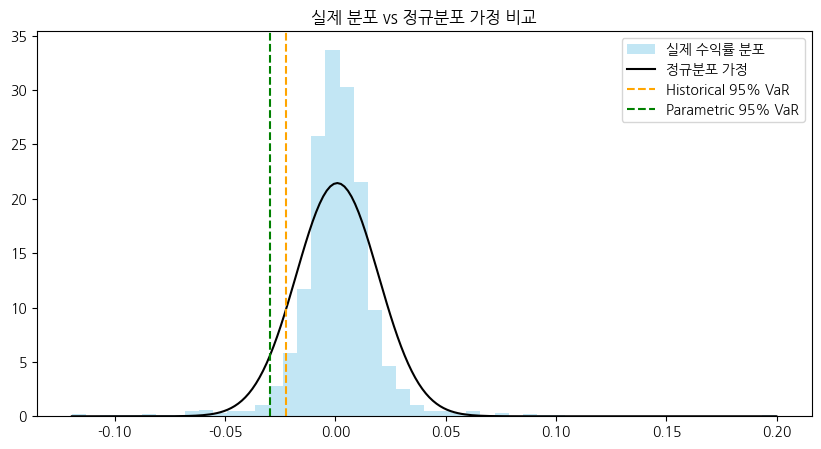

In [15]:
plt.figure(figsize=(10,5))
plt.hist(df['Return'], bins=50, density=True, alpha=0.5, color='skyblue', label='실제 수익률 분포')

x = np.linspace(df['Return'].min(), df['Return'].max(), 200)
plt.plot(x, norm.pdf(x, mean_return, std_return), color='black', label='정규분포 가정')

plt.axvline(-var_95, color='orange', linestyle='--', label=f'Historical 95% VaR')
plt.axvline(-var_param_95, color='green', linestyle='--', label=f'Parametric 95% VaR')
plt.legend()
plt.title('실제 분포 vs 정규분포 가정 비교')
plt.show()

In [16]:
df_stress = fdr.DataReader('KS200', '2019-01-01', '2023-12-31')
df_stress = df_stress[['Close']]
df_stress['Return'] = df_stress['Close'].pct_change()
df_stress = df_stress.dropna()
df_stress.head()

,Close,Return
Date,,
2019-01-03,255.77,-0.009526
2019-01-04,257.89,0.008289
2019-01-07,261.57,0.014270
2019-01-08,259.65,-0.007340
2019-01-09,265.60,0.022915


In [17]:
scenarios = {
    '코로나 폭락 (2020.02.19~2020.03.19)': ('2020-02-19', '2020-03-19'),
    '2022년 금리인상기 (2022.01.01~2022.09.30)': ('2022-01-01', '2022-09-30'),
}

scenario_results = {}
for name, (start, end) in scenarios.items():
    period = df_stress.loc[start:end]
    cumulative_return = (1 + period['Return']).prod() - 1
    worst_day = period['Return'].min()
    scenario_results[name] = {
        '누적수익률': cumulative_return,
        '최악의 하루': worst_day
    }
    print(f"[{name}]")
    print(f"  누적 수익률: {cumulative_return*100:.2f}%")
    print(f"  최악의 하루 수익률: {worst_day*100:.2f}%\n")

[코로나 폭락 (2020.02.19~2020.03.19)]
  누적 수익률: -33.07%
  최악의 하루 수익률: -7.67%

[2022년 금리인상기 (2022.01.01~2022.09.30)]
  누적 수익률: -28.62%
  최악의 하루 수익률: -3.51%



In [18]:
portfolio_value = 100_000_000  # 1억원 가정

print("=== VaR 기반 예상 손실 (평상시 통계 모델) ===")
print(f"95% VaR 하루 예상 손실: {portfolio_value*var_95:,.0f}원")
print(f"99% VaR 하루 예상 손실: {portfolio_value*var_99:,.0f}원\n")

print("=== 스트레스 시나리오 실제 손실 ===")
for name, result in scenario_results.items():
    daily_loss = portfolio_value * abs(result['최악의 하루'])
    total_loss = portfolio_value * abs(result['누적수익률'])
    print(f"[{name}]")
    print(f"  최악의 하루 손실액: {daily_loss:,.0f}원")
    print(f"  전체 기간 누적 손실액: {total_loss:,.0f}원\n")

=== VaR 기반 예상 손실 (평상시 통계 모델) ===
95% VaR 하루 예상 손실: 2,225,137원
99% VaR 하루 예상 손실: 6,083,087원

=== 스트레스 시나리오 실제 손실 ===
[코로나 폭락 (2020.02.19~2020.03.19)]
  최악의 하루 손실액: 7,668,072원
  전체 기간 누적 손실액: 33,069,121원

[2022년 금리인상기 (2022.01.01~2022.09.30)]
  최악의 하루 손실액: 3,512,826원
  전체 기간 누적 손실액: 28,623,253원



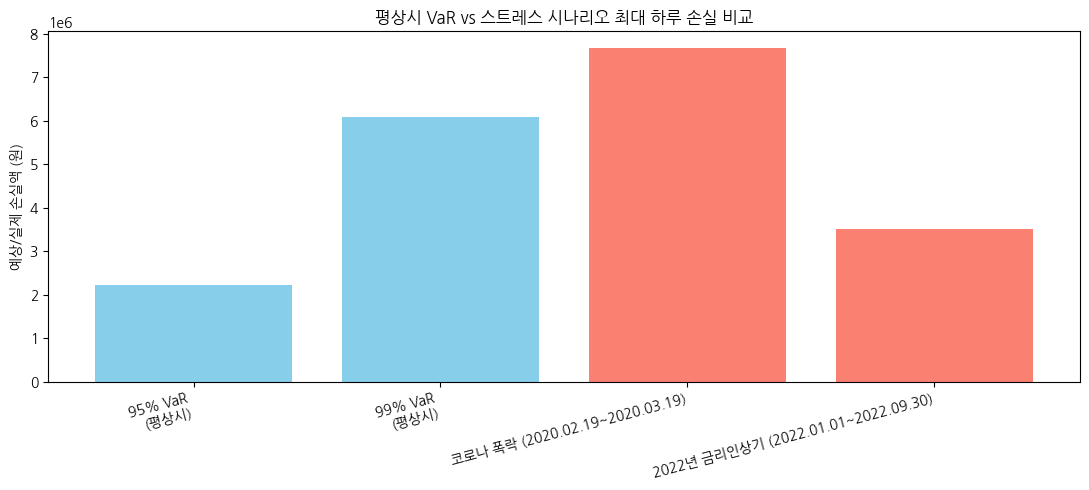

In [19]:
labels = ['95% VaR\n(평상시)', '99% VaR\n(평상시)'] + list(scenario_results.keys())
values = [portfolio_value*var_95, portfolio_value*var_99] + \
         [portfolio_value*abs(r['최악의 하루']) for r in scenario_results.values()]

plt.figure(figsize=(11,5))
colors = ['skyblue', 'skyblue', 'salmon', 'salmon']
plt.bar(labels, values, color=colors)
plt.ylabel('예상/실제 손실액 (원)')
plt.title('평상시 VaR vs 스트레스 시나리오 최대 하루 손실 비교')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()